In [ ]:
!pip install transformers datasets peft accelerate sentencepiece bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
'''from google.colab import drive
drive.mount('/content/drive')'''

Mounted at /content/drive


In [ ]:
!pip install transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.2 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import MT5ForConditionalGeneration, MT5Tokenizer
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType


In [ ]:
import pandas as pd
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/combined_data.csv')

In [ ]:
from datasets import Dataset

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1,seed=42)  # 90% train, 10% test


In [ ]:
dataset["train"].shape, dataset["test"].shape

((4543, 2), (505, 2))

In [ ]:
from transformers import AutoTokenizer
model_name = "google/mt5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False, legacy=False)
base_model = MT5ForConditionalGeneration.from_pretrained(model_name)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,  # Sequence-to-sequence task
    r=32,  # Rank of LoRA
    lora_alpha=32,  # Scaling factor
    lora_dropout=0.1,  # Dropout for LoRA layers
    target_modules=["q", "v"]  # Apply LoRA to attention layers
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()  # Check trainable parameters


trainable params: 1,376,256 || all params: 301,553,024 || trainable%: 0.4564


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
max_input_length = 512
max_target_length = 128

def preprocess_data(batch):
    inputs = tokenizer(batch["formatted_article"], max_length=max_input_length, truncation=True, padding="max_length", return_tensors="pt")
    targets = tokenizer(batch["nepali_summary"], max_length=max_target_length, truncation=True, padding="max_length", return_tensors="pt")

    return {
        "input_ids": inputs["input_ids"].squeeze(),
        "attention_mask": inputs["attention_mask"].squeeze(),
        "labels": targets["input_ids"].squeeze()
    }

train_dataset = dataset["train"].map(preprocess_data, batched=True)
test_dataset = dataset["test"].map(preprocess_data, batched=True)


Map:   0%|          | 0/4543 [00:00<?, ? examples/s]

Map:   0%|          | 0/505 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./mt5_nepali_summarizer",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-4,
    per_device_train_batch_size=5,
    per_device_eval_batch_size=5,
    num_train_epochs=5,
    weight_decay=0.05,
    logging_dir="./logs",
    push_to_hub=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,2.407700,1.676816
2,2.245400,1.667171
3,2.135200,1.594722
4,2.055100,1.563942
5,2.011900,1.569790


TrainOutput(global_step=4545, training_loss=2.1650946890953744, metrics={'train_runtime': 1453.7205, 'train_samples_per_second': 15.625, 'train_steps_per_second': 3.126, 'total_flos': 1.210658503262208e+16, 'train_loss': 2.1650946890953744, 'epoch': 5.0})

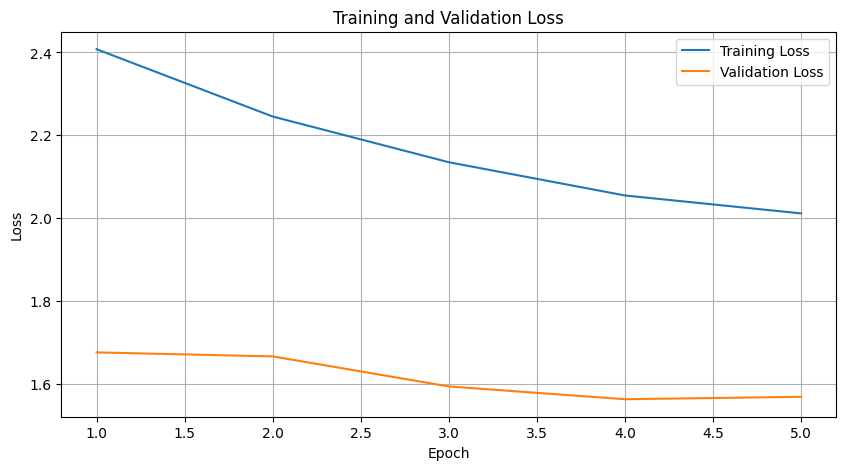

In [ ]:
import matplotlib.pyplot as plt

# Epoch and Loss data
epoch = [1, 2, 3, 4, 5]
train_loss = [2.407700, 2.245400, 2.135200, 2.055100, 2.011900]
val_loss = [1.676816, 1.667171, 1.594722, 1.563942, 1.569790]

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(epoch, train_loss, label='Training Loss')
plt.plot(epoch, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Save trained model
model.save_pretrained('/content/drive/MyDrive/mt5_small_lora2(epo5)')
tokenizer.save_pretrained('/content/drive/MyDrive/mt5_small_lora2(epo5)')

('/content/drive/MyDrive/mt5_small_lora2(epo5)/tokenizer_config.json',
 '/content/drive/MyDrive/mt5_small_lora2(epo5)/special_tokens_map.json',
 '/content/drive/MyDrive/mt5_small_lora2(epo5)/spiece.model',
 '/content/drive/MyDrive/mt5_small_lora2(epo5)/added_tokens.json')